In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_half_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

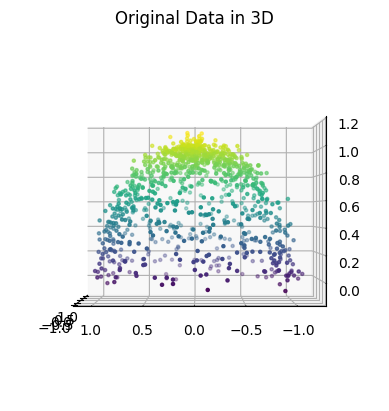

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

model_path = "models/conformal_autoencoder_half_sphere.pth"
optimizer_path = "models/conformal_autoencoder_half_sphere_optimizer.pth"

In [6]:
from metrics import conformality_angle_loss

In [7]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
conformal_autoencoder = ConformalAutoencoder(encoder, decoder, lambda_conf=10.0).to(device)
conformal_autoencoder.conformality_loss = conformality_angle_loss
optmizer, scheduler = conformal_autoencoder.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=1000, learning_rate=0.001, log_every=100, val_every=100, scheduler_kwargs={"step_size": 100, "gamma": 0.5})

/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [100/1000], Loss: 0.00272394, Reconstruction Loss: 0.00174067, Conformal Loss: 0.00009833
Epoch [100/1000], Validation Loss: 0.00274228, Reconstruction Loss: 0.00164008, Conformal Loss: 0.00011022
Epoch [200/1000], Loss: 0.00179385, Reconstruction Loss: 0.00129659, Conformal Loss: 0.00004973
Epoch [200/1000], Validation Loss: 0.00249882, Reconstruction Loss: 0.00165672, Conformal Loss: 0.00008421
Epoch [300/1000], Loss: 0.00144451, Reconstruction Loss: 0.00106807, Conformal Loss: 0.00003764
Epoch [300/1000], Validation Loss: 0.00168263, Reconstruction Loss: 0.00115372, Conformal Loss: 0.00005289
Epoch [400/1000], Loss: 0.00134073, Reconstruction Loss: 0.00099770, Conformal Loss: 0.00003430
Epoch [400/1000], Validation Loss: 0.00157535, Reconstruction Loss: 0.00108140, Conformal Loss: 0.00004939
Epoch [500/1000], Loss: 0.00123037, Reconstruction Loss: 0.00093477, Conformal Loss: 0.00002956
Epoch [500/1000], Validation Loss: 0.00142628, Reconstruction Loss: 0.00105213, Conformal Lo

In [7]:
conformal_autoencoder.save_checkpoint(model_path)
save_optimizer_and_scheduler(optimizer_path, optmizer, scheduler)

Checkpoint saved to models/conformal_autoencoder_half_sphere.pth at epoch 1001
Optimizer and scheduler saved to models/conformal_autoencoder_half_sphere_optimizer.pth


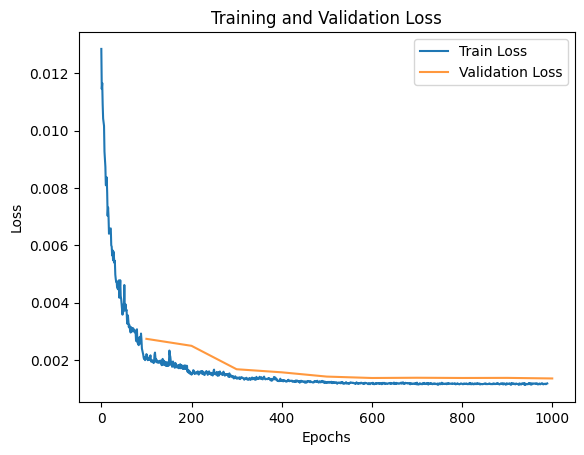

In [8]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

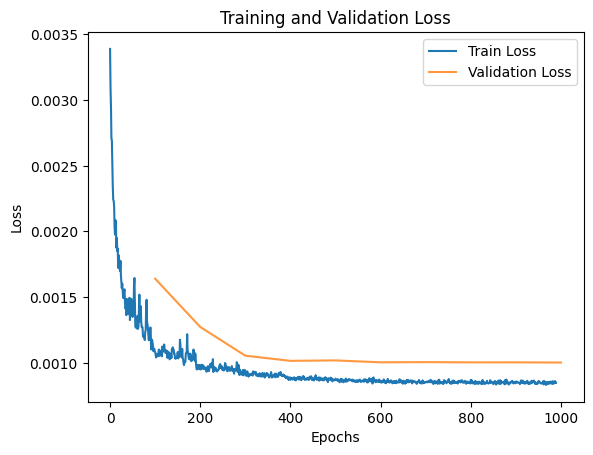

In [8]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

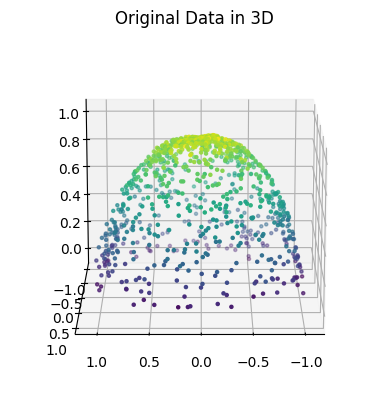

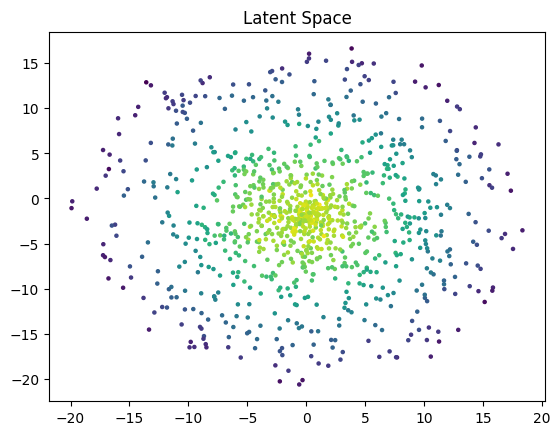

In [9]:
#Encode the data
encoded_data = conformal_autoencoder.encode(data)
# Decode the data
decoded_data = conformal_autoencoder.decode(encoded_data).cpu().detach()
encoded_data = encoded_data.cpu().detach()

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [ ]:
num = 900
J = torch.zeros((num, 2, 2))
J_trace = torch.zeros(num)
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
    J_trace[i] = torch.trace(J[i])
print(J.mean(dim=0))
print(J.std(dim=0))

J_trace = J_trace.unsqueeze(1).unsqueeze(2).repeat(1,2,2)
normed_J = J / J_trace * 2

tensor([[7.7700e-03, 1.1867e-05],
        [1.1867e-05, 7.7758e-03]])
tensor([[0.0026, 0.0005],
        [0.0005, 0.0025]])


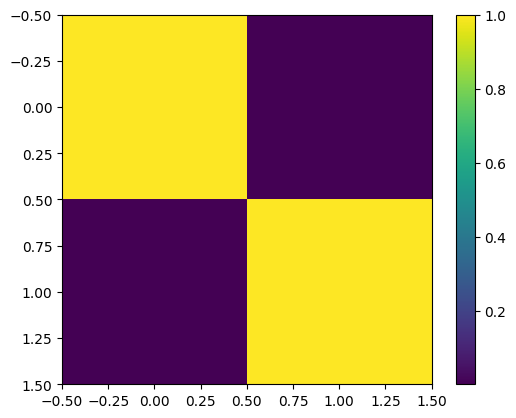

In [ ]:
plt.imshow(normed_J.mean(dim=0).cpu().numpy(), cmap='viridis')
plt.colorbar()

In [ ]:
def gini_coefficient(x: torch.Tensor) -> torch.Tensor:
    """Compute the Gini coefficient of a 1D torch tensor."""
    if x.numel() == 0:
        return torch.tensor(0.0, dtype=x.dtype, device=x.device)
    
    x = x.flatten()
    if torch.any(x < 0):
        raise ValueError("Gini coefficient is not defined for negative values")

    # Sort
    sorted_x, _ = torch.sort(x)
    n = x.numel()
    index = torch.arange(1, n + 1, dtype=x.dtype, device=x.device)
    
    # Gini formula
    gini = (2 * torch.sum(index * sorted_x) / torch.sum(sorted_x) - (n + 1)) / n
    return gini


In [81]:
off_diag = normed_J.mean(dim=0) - torch.diag(normed_J.mean(dim=0))* torch.eye(2)
# how similar are the diagonal elemets?
gini = gini_coefficient(torch.diag(normed_J.mean(dim=0)))
# how big are the off-diagonal elements?
off_diag_mean = off_diag.abs().mean()
print(f"Gini Coefficient: {gini.item()}")
print(f"Off-diagonal mean: {off_diag_mean.item()}")

Gini Coefficient: 0.0006291866302490234
Off-diagonal mean: 0.0009383900905959308


In [92]:
(normed_J - torch.eye(2)).abs().mean()

tensor(0.0488)

In [12]:
# Load the model and optimizer from checkpoint
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
autoencoder = ConformalAutoencoder(encoder, decoder).load_model_from_checkpoint(model_path).to(device)
optimizer = autoencoder.get_default_optimizer()
scheduler = autoencoder.get_default_scheduler(optimizer)
optimizer, scheduler = load_optimizer_and_scheduler(optimizer_path, optimizer, scheduler)

Model and custom variables loaded from models/conformal_autoencoder_half_sphere.pth
Optimizer and scheduler loaded from models/conformal_autoencoder_half_sphere_optimizer.pth
